# SmartCart: Part 3: Association Rule Mining (Apriori)

##  Imports

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules

pd.set_option('display.max_columns', None)
np.random.seed(42)

## 3.1  Load Data & Convert User Interactions into Transactions

In [18]:
import pandas as pd
import numpy as np

# --- Load data ---
user_data = pd.read_csv('ecommerce_user_data.csv')
product_data = pd.read_csv('product_details.csv')

# --- Basic cleaning ---
user_data['Timestamp'] = pd.to_datetime(user_data['Timestamp'])
user_data = user_data.drop_duplicates(['UserID', 'ProductID'], keep='last')

# --- Build transactions (user → list of products) ---
transactions = (
    user_data.groupby('UserID')['ProductID']
    .apply(lambda x: list(set(x)))
    .tolist()
)

# --- Quick stats ---
basket_sizes = [len(t) for t in transactions]

print("Users:", user_data['UserID'].nunique())
print("Products:", user_data['ProductID'].nunique())
print("Transactions:", len(transactions))
print("Avg basket size:", np.mean(basket_sizes))
print("Min/Max basket size:", min(basket_sizes), "/", max(basket_sizes))

print("\nExample basket:")
print(transactions[0])

Users: 50
Products: 100
Transactions: 50
Avg basket size: 14.48
Min/Max basket size: 10 / 20

Example basket:
['P0020', 'P0048', 'P0012', 'P0013', 'P0046', 'P0007', 'P0079', 'P0003', 'P0009', 'P0047', 'P0042', 'P0071', 'P0021', 'P0014', 'P0050', 'P0028', 'P0033', 'P0005', 'P0070', 'P0044']


## 3.2  One-Hot Encode the Transaction Baskets


In [19]:
te = TransactionEncoder()
te_array = te.fit(transactions).transform(transactions)

transaction_df = pd.DataFrame(te_array, columns=te.columns_)

print("Transaction matrix shape:", transaction_df.shape)
transaction_df.head()

Transaction matrix shape: (50, 100)


,P0000,P0001,P0002,P0003,P0004,P0005,P0006,P0007,P0008,P0009,P0010,P0011,P0012,P0013,P0014,P0015,P0016,P0017,P0018,P0019,P0020,P0021,P0022,P0023,P0024,P0025,P0026,P0027,P0028,P0029,P0030,P0031,P0032,P0033,P0034,P0035,P0036,P0037,P0038,P0039,P0040,P0041,P0042,P0043,P0044,P0045,P0046,P0047,P0048,P0049,P0050,P0051,P0052,P0053,P0054,P0055,P0056,P0057,P0058,P0059,P0060,P0061,P0062,P0063,P0064,P0065,P0066,P0067,P0068,P0069,P0070,P0071,P0072,P0073,P0074,P0075,P0076,P0077,P0078,P0079,P0080,P0081,P0082,P0083,P0084,P0085,P0086,P0087,P0088,P0089,P0090,P0091,P0092,P0093,P0094,P0095,P0096,P0097,P0098,P0099
0,False,False,False,True,False,True,False,True,False,True,False,False,True,True,True,False,False,False,False,False,True,True,False,False,False,False,False,False,True,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,True,False,True,True,True,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,True,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,True,True,False,False,True,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,True,False,False,False,True,False,False,False,False
2,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,True,False,True,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False,True,True,False,False,False,False,False,False,False,False,True,False,True,False,True,True,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False
4,False,True,False,False,False,False,True,False,False,False,False,True,False,False,True,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,True,False,False,False,False,False,True,False,True,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,True,False,False,True,False,True,False,False,False,True,False,False,False,False,False,True,True


## 3.3  Frequent Itemsets


In [ ]:
# A 10% support threshold gives a manageable number of itemsets/rules on this dataset.
min_support = 0.10

frequent_itemsets = apriori(
    transaction_df,
    min_support=min_support,
    use_colnames=True
)

frequent_itemsets['itemset_length'] = frequent_itemsets['itemsets'].apply(len)
frequent_itemsets = frequent_itemsets.sort_values(
    by=['support', 'itemset_length'],
    ascending=[False, False]
).reset_index(drop=True)

print(f"Frequent itemsets found: {len(frequent_itemsets)}")
print("\nItemsets by size:")
print(frequent_itemsets['itemset_length'].value_counts().sort_index())

frequent_itemsets.head(10)

Frequent itemsets found: 109

Itemsets by size:
itemset_length
1    91
2    18
Name: count, dtype: int64


,support,itemsets,itemset_length
0,0.34,frozenset({P0070}),1
1,0.26,frozenset({P0051}),1
2,0.26,frozenset({P0089}),1
3,0.24,frozenset({P0043}),1
4,0.24,frozenset({P0088}),1
5,0.22,frozenset({P0004}),1
6,0.22,frozenset({P0030}),1
7,0.22,frozenset({P0044}),1
8,0.22,frozenset({P0065}),1
9,0.22,frozenset({P0077}),1


## 3.4  Association Rules


Interpretation:
- higher confidence means the consequent often appears when the antecedent appears
- lift > 1 suggests a positive association stronger than random chance

In [21]:
min_confidence = 0.50

rules = association_rules(
    frequent_itemsets,
    metric='confidence',
    min_threshold=min_confidence
)

rules = rules[[
    'antecedents', 'consequents',
    'support', 'confidence', 'lift'
]].copy()

rules = rules.sort_values(
    by=['lift', 'confidence', 'support'],
    ascending=False
).reset_index(drop=True)

print(f"Association rules found: {len(rules)}")
rules.head(10)

Association rules found: 19


,antecedents,consequents,support,confidence,lift
0,frozenset({P0039}),frozenset({P0015}),0.1,0.714286,4.464286
1,frozenset({P0015}),frozenset({P0039}),0.1,0.625000,4.464286
2,frozenset({P0013}),frozenset({P0079}),0.1,0.714286,3.571429
3,frozenset({P0079}),frozenset({P0013}),0.1,0.500000,3.571429
4,frozenset({P0076}),frozenset({P0065}),0.1,0.714286,3.246753
5,frozenset({P0042}),frozenset({P0070}),0.1,1.000000,2.941176
6,frozenset({P0011}),frozenset({P0004}),0.1,0.555556,2.525253
7,frozenset({P0011}),frozenset({P0077}),0.1,0.555556,2.525253
8,frozenset({P0079}),frozenset({P0064}),0.1,0.500000,2.500000
9,frozenset({P0064}),frozenset({P0079}),0.1,0.500000,2.500000


## 3.5  Making the Results Human-Readable

In [23]:
product_lookup = product_data.set_index('ProductID')[['ProductName', 'Category']]


def itemset_to_product_names(itemset):
    """Convert a frozenset of ProductIDs into readable product names."""
    return ", ".join(
        product_lookup.loc[pid, 'ProductName'] if pid in product_lookup.index else pid
        for pid in sorted(itemset)
    )


frequent_itemsets['itemset_names'] = frequent_itemsets['itemsets'].apply(itemset_to_product_names)

rules['antecedents_names'] = rules['antecedents'].apply(itemset_to_product_names)
rules['consequents_names'] = rules['consequents'].apply(itemset_to_product_names)
rules['rule'] = rules['antecedents_names'] + '  →  ' + rules['consequents_names']

print("Top frequent itemsets:")
display(
    frequent_itemsets[['support', 'itemset_length', 'itemset_names']].head(10)
)

print("Top association rules:")
display(
    rules[['rule', 'support', 'confidence', 'lift']].head(10)
)

Top frequent itemsets:


,support,itemset_length,itemset_names
0,0.34,1,Beauty Item 70
1,0.26,1,Home Item 51
2,0.26,1,Clothing Item 89
3,0.24,1,Books Item 43
4,0.24,1,Clothing Item 88
5,0.22,1,Clothing Item 4
6,0.22,1,Books Item 30
7,0.22,1,Clothing Item 44
8,0.22,1,Toys Item 65
9,0.22,1,Home Item 77


Top association rules:


,rule,support,confidence,lift
0,Toys Item 39 → Toys Item 15,0.1,0.714286,4.464286
1,Toys Item 15 → Toys Item 39,0.1,0.625000,4.464286
2,Clothing Item 13 → Home Item 79,0.1,0.714286,3.571429
3,Home Item 79 → Clothing Item 13,0.1,0.500000,3.571429
4,Home Item 76 → Toys Item 65,0.1,0.714286,3.246753
5,Clothing Item 42 → Beauty Item 70,0.1,1.000000,2.941176
6,Books Item 11 → Clothing Item 4,0.1,0.555556,2.525253
7,Books Item 11 → Home Item 77,0.1,0.555556,2.525253
8,Home Item 79 → Electronics Item 64,0.1,0.500000,2.500000
9,Electronics Item 64 → Home Item 79,0.1,0.500000,2.500000


## 3.6  Visualisations

### (a) Top Frequent Itemsets by Support

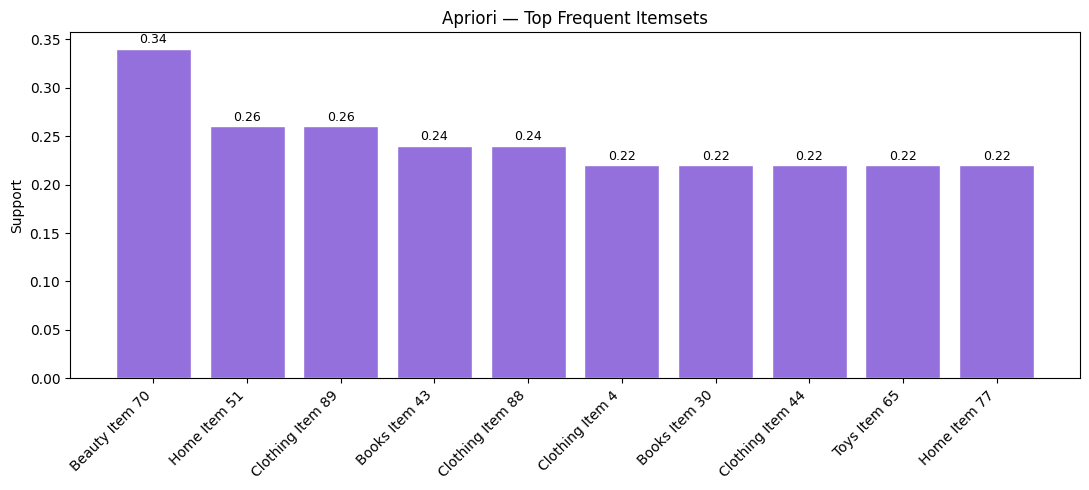

In [ ]:
frequent_itemsets[['support', 'itemset_length', 'itemset_names']].to_csv(
    'part3_frequent_itemsets.csv', index=False
)

rules[['rule', 'support', 'confidence', 'lift']].to_csv(
    'part3_association_rules.csv', index=False
)

print("Saved: part3_frequent_itemsets.csv")
print("Saved: part3_association_rules.csv")

top_itemsets = frequent_itemsets.head(10).copy()

fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(top_itemsets['itemset_names'], top_itemsets['support'],
       color='mediumpurple', edgecolor='white')

ax.set_ylabel('Support')
ax.set_title('Apriori — Top Frequent Itemsets')
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))
plt.xticks(rotation=45, ha='right')

for i, val in enumerate(top_itemsets['support']):
    ax.annotate(f'{val:.2f}',
                xy=(i, val),
                xytext=(0, 4),
                textcoords='offset points',
                ha='center',
                fontsize=9)

plt.tight_layout()
plt.savefig('part3_top_itemsets.png', dpi=150)
plt.show()

### (b) Top Association Rules by Lift

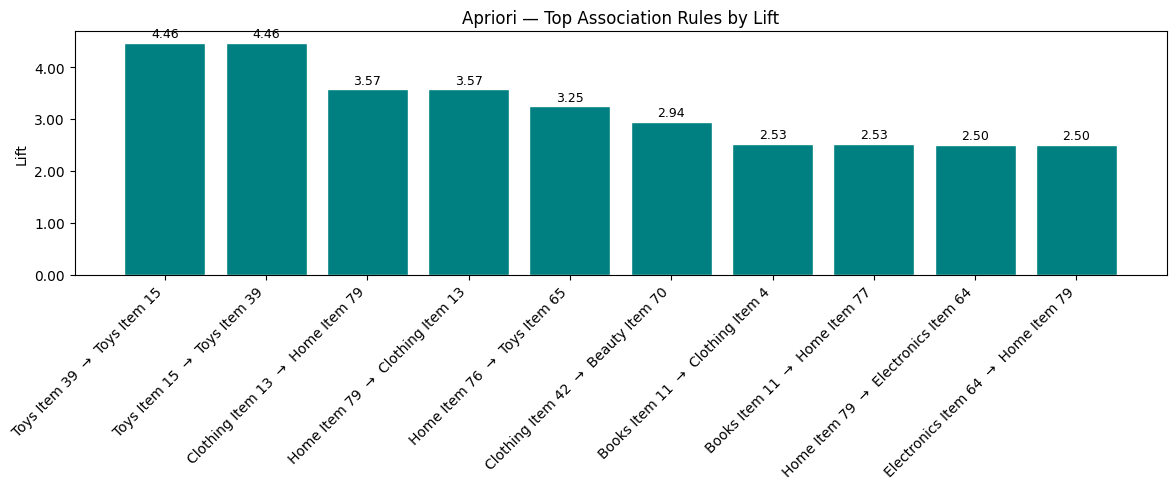

In [10]:
top_rules = rules.head(10).copy()

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(top_rules['rule'], top_rules['lift'],
       color='teal', edgecolor='white')

ax.set_ylabel('Lift')
ax.set_title('Apriori — Top Association Rules by Lift')
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))
plt.xticks(rotation=45, ha='right')

for i, val in enumerate(top_rules['lift']):
    ax.annotate(f'{val:.2f}',
                xy=(i, val),
                xytext=(0, 4),
                textcoords='offset points',
                ha='center',
                fontsize=9)

plt.tight_layout()
plt.savefig('part3_top_rules_by_lift.png', dpi=150)
plt.show()

### (c) Part 3 Summary Table

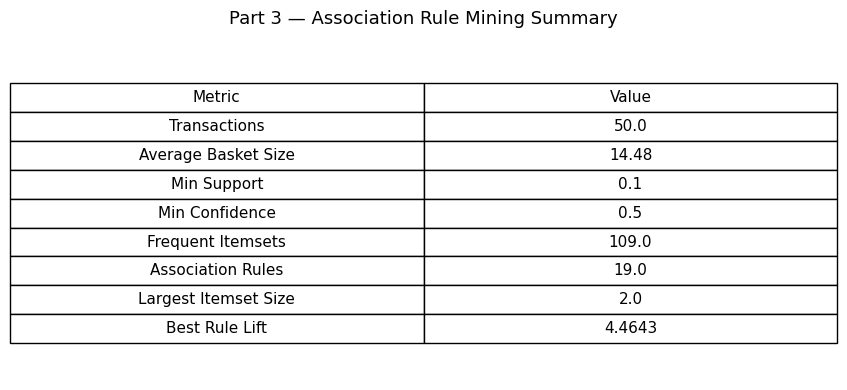

              Metric    Value
        Transactions  50.0000
 Average Basket Size  14.4800
         Min Support   0.1000
      Min Confidence   0.5000
   Frequent Itemsets 109.0000
   Association Rules  19.0000
Largest Itemset Size   2.0000
      Best Rule Lift   4.4643


In [11]:
summary = pd.DataFrame({
    'Metric': [
        'Transactions',
        'Average Basket Size',
        'Min Support',
        'Min Confidence',
        'Frequent Itemsets',
        'Association Rules',
        'Largest Itemset Size',
        'Best Rule Lift'
    ],
    'Value': [
        len(transactions),
        round(np.mean(basket_sizes), 2),
        min_support,
        min_confidence,
        len(frequent_itemsets),
        len(rules),
        frequent_itemsets['itemset_length'].max(),
        round(rules['lift'].max(), 4) if len(rules) else np.nan
    ]
})

fig, ax = plt.subplots(figsize=(9, 4))
ax.axis('off')
tbl = ax.table(
    cellText=summary.values,
    colLabels=summary.columns,
    cellLoc='center',
    loc='center'
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(11)
tbl.scale(1.4, 1.6)

plt.title('Part 3 — Association Rule Mining Summary', fontsize=13, pad=16)
plt.tight_layout()
plt.savefig('part3_summary_table.png', dpi=150)
plt.show()

print(summary.to_string(index=False))

### Key Observations
- The data was converted into 50 user-level transaction baskets, with an average basket size of about 14.48 products.

- Using a minimum support of 0.10 kept the results simple while still capturing useful co-occurrence patterns.

- Most frequent itemsets were single items or pairs, which makes sense since larger combinations happen less often.

- The strongest rules had lift values greater than 1, meaning those product combinations appear together more often than random chance.

- Since this dataset reflects user interactions (not actual purchases), these rules should be seen as patterns of shared interest and not 
guaranteed product bundles.